In [1]:
!python packages.py

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import json
from GPTQE import GPTQE
from model import GPTConfig
import pandas as pd
from train import get_subsequence_energies, build_operator_pool
import pennylane as qml
from hamiltonian import gen_hamiltonian
from collections import Counter
import joblib
from numpy.random import default_rng
import random
import itertools
from qiskit import QuantumCircuit, transpile
from pennylane import numpy as npp
from scipy.optimize import minimize

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [3]:
def average_checkpoints(checkpoint_paths):
    """
    Averages the weights of three model checkpoints.

    Args:
        checkpoint_paths (list): List of strings containing paths to .pt or .pth files.

    Returns:
        dict: A new state_dict containing the averaged weights.
    """
    # if len(checkpoint_paths) != 3:
    #     raise ValueError("This function specifically requires exactly three checkpoint paths.")

    # Load the state dicts into memory
    # map_location='cpu' ensures you don't blow up your VRAM during the merge
    final_dicts = [torch.load(p, map_location='cpu') for p in checkpoint_paths]
    state_dicts = [d["model_state_dict"] for d in final_dicts]

    # Use the first model as a template for the keys
    averaged_dict = {}
    keys = state_dicts[0].keys()

    for key in keys:
        # Check if the parameter is a tensor (weights/biases) or just metadata
        if isinstance(state_dicts[0][key], torch.Tensor):
            # Stack the same layer from all 3 models and take the mean along the new dimension
            # Formula: (W1 + W2 + W3) / 3
            averaged_dict[key] = torch.stack([sd[key] for sd in state_dicts]).mean(dim=0)
        else:
            # For non-tensor items (like version numbers), just keep the value from the first model
            averaged_dict[key] = state_dicts[0][key]

    return averaged_dict

# Usage Example:
# paths = ["model_a.pth", "model_b.pth", "model_c.pth"]
# new_weights = average_checkpoints(paths)

In [5]:
dir = "heisenberg_(10,10)(M=10, b=0.3)(37M)"

with open(f"{dir}/config.json") as f:
    config = json.load(f)

with open(f"{dir}/metadata.json") as g:
    metadata = json.load(g)

model = GPTQE(GPTConfig(
    vocab_size=config["vocab_size"],
    block_size=config["block_size"],
    dropout=config["dropout"],
    bias=config["bias"],
    n_layer=config["n_layer"],
    n_embd=config["n_embd"],
    n_head=config["n_head"],
)).to("cpu")

# Load specific checkpoint
load = torch.load(f"{dir}/checkpoint500.pt", map_location="cpu")
model.load_state_dict(load["model_state_dict"])

# Load average weights of multiple checkpoints
# best_epochs = metadata["best checkpoints"]
# print(best_epochs)
# paths = [f"{dir}/checkpoint{i}.pt" for i in best_epochs]
# # paths = ["heisenberg_(10,10)(37M, lrdown,b=1)*/checkpoint300.pt", "heisenberg_(1,10)(37M, lrdown,b=1)*/checkpoint500.pt"]
# model.load_state_dict(average_checkpoints(paths))


op_pool = np.array(build_operator_pool(4), dtype=object)
ham = gen_hamiltonian(1, 4, 10, 10)
init_state = [0, 0, 0, 0]
num_qubits = 4
grd_E = np.linalg.eigh(qml.matrix(ham))[0][0]
grd_E

number of parameters: 37.83M


-64.64101615137754

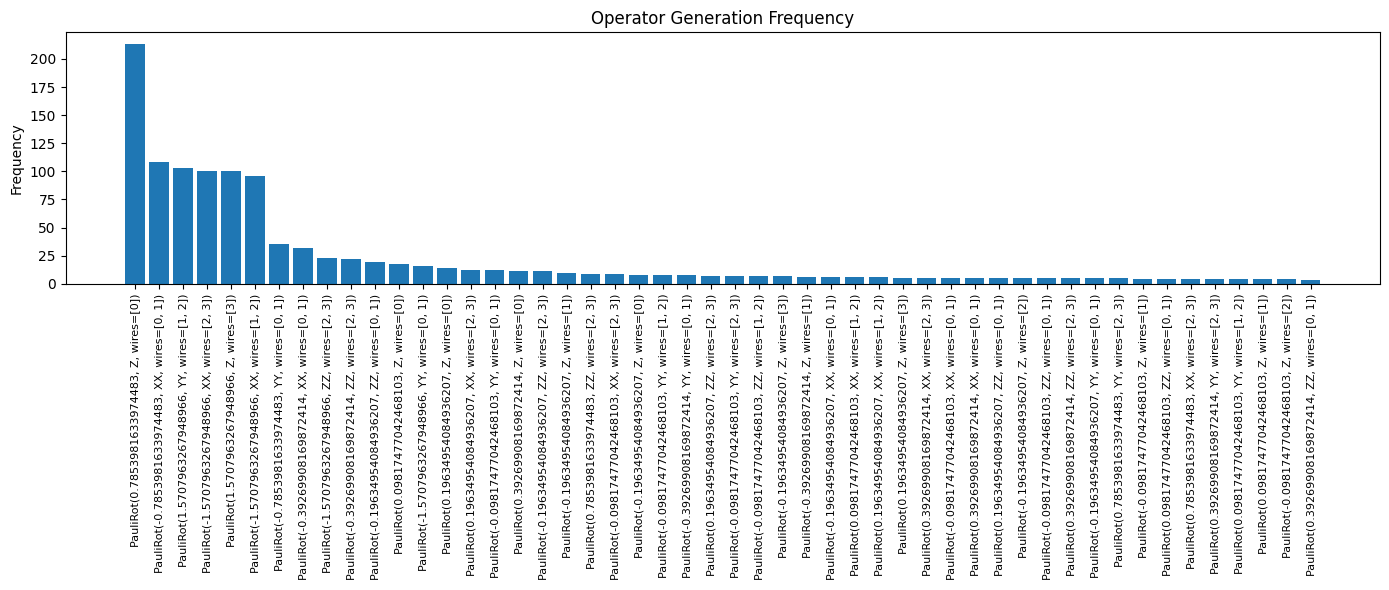

4.135500949810338 -52.958043946278565 -60.152526965464304
[PauliRot(1.5707963267948966, YY, wires=[1, 2])
 PauliRot(1.5707963267948966, YY, wires=[1, 2])
 PauliRot(-1.5707963267948966, XX, wires=[2, 3])
 PauliRot(1.5707963267948966, Z, wires=[3])
 PauliRot(-0.7853981633974483, XX, wires=[0, 1])
 PauliRot(0.7853981633974483, Z, wires=[0])
 PauliRot(-0.09817477042468103, ZZ, wires=[1, 2])
 PauliRot(0.7853981633974483, Z, wires=[0])
 PauliRot(-1.5707963267948966, YY, wires=[0, 1])
 PauliRot(0.7853981633974483, Z, wires=[0])
 PauliRot(-0.19634954084936207, Z, wires=[0])
 PauliRot(-0.09817477042468103, XX, wires=[0, 1])] tensor([[-60.1525]], dtype=torch.float64) [-58.69163]
[PauliRot(1.5707963267948966, YY, wires=[1, 2])
 PauliRot(1.5707963267948966, YY, wires=[1, 2])
 PauliRot(-1.5707963267948966, XX, wires=[2, 3])
 PauliRot(1.5707963267948966, Z, wires=[3])
 PauliRot(-0.7853981633974483, XX, wires=[0, 1])
 PauliRot(0.7853981633974483, Z, wires=[0])
 PauliRot(-0.09817477042468103, XX, wire

In [6]:
model.eval()
with torch.no_grad():
    gen_token_seq, pred_Es = model.generate(
        n_sequences=100,
        max_new_tokens=12,
        temperature=.5, # Use a low temperature to emphasize the difference in logits (play with temp)
        device="cpu"
    )

pred_Es = pred_Es.detach().cpu().numpy()

gen_inds = (gen_token_seq[:, 1:] - 1).cpu().numpy()
gen_op_seq = op_pool[gen_inds]
true_Es = get_subsequence_energies(gen_op_seq, ham, init_state, num_qubits)[:, -1].reshape(-1, 1)

tok_dict = {}
for token in gen_op_seq.flatten():
    if token not in tok_dict.keys():
        tok_dict[token] = 1
    else:
        tok_dict[token] += 1

token_str_counts = Counter({str(k): v for k, v in tok_dict.items()})

# Get most common tokens
top_tokens = token_str_counts.most_common(50)
labels, values = zip(*top_tokens)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(range(len(labels)), values)
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
plt.ylabel("Frequency")
plt.title("Operator Generation Frequency")
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(pred_Es - true_Es))
ave_E = np.mean(true_Es)
min_E = np.min(true_Es)
print(mae, ave_E, min_E)

true_Es = torch.tensor(true_Es)
best_idx = torch.topk(-true_Es, k=5, dim=0).indices

for idx in best_idx:
    print(gen_op_seq[idx], true_Es[idx], pred_Es[idx])

In [7]:
def angle_refinement(gpt_sequence, hamiltonian, init_state, num_qubits):
    dev = qml.device("default.qubit", wires=num_qubits)

    # 1. Safely extract parameters and structure
    # We use qml.math.toarray to avoid the memoryview/format O error
    initial_angles = []
    pauli_strings = []
    gate_wires = []

    for gate in gpt_sequence:
        # Extract the angle (parameter)
        angle = qml.math.toarray(gate.parameters[0]).item()
        initial_angles.append(angle)

        # Extract the Pauli word (e.g., "XXI")
        # PauliRot stores this in its 'hyperparameters'
        pauli_strings.append(gate.hyperparameters["pauli_word"])
        gate_wires.append(gate.wires)

    initial_params = npp.array(initial_angles, requires_grad=True)

    # 2. Define the QNode
    @qml.qnode(dev)
    def cost_function(params):
        qml.BasisState(npp.array(init_state), wires=range(num_qubits))

        for i in range(len(pauli_strings)):
            # Reconstruct the gate with the new parameter
            qml.PauliRot(params[i], pauli_strings[i], wires=gate_wires[i])

        return qml.expval(hamiltonian)

    # 3. Optimization Phase
    # print(f"GPT Energy (Pre-optimization): {cost_function(initial_params):.4f}")

    # We use 'L-BFGS-B' for precise local convergence
    res = minimize(
        cost_function, 
        initial_params, 
        method='L-BFGS-B', 
        tol=1e-8
    )

    # print(f"Refined Energy: {res.fun:.4f}")
    return res.fun, res.x

# Example:
# for i in range(5):
#     best_seq = gen_op_seq[best_idx[i]]
#     result_energy, result_angles = refine_pauli_rot_circuit(best_seq, ham, init_state, num_qubits)
#     print(result_energy)

In [8]:
def wire_shift_refinement(best_seq, ham, init_state, num_qubits):
    current_seq = list(best_seq)
    # Get baseline
    current_energy, current_angles = angle_refinement(current_seq, ham, init_state, num_qubits)

    print(f"Starting Wire-Shift Refinement at Energy: {current_energy:.4f}")

    # Pre-calculate possible wire combinations
    all_qubits = list(range(num_qubits))
    two_qubit_pairs = list(itertools.combinations(all_qubits, 2))
    one_qubit_slots = [(q,) for q in all_qubits]

    for i in range(len(current_seq)):
        original_gate = current_seq[i]
        num_target_wires = len(original_gate.wires)
        if num_target_wires == 1:
            continue
        else:
            best_wires_for_pos = original_gate.wires

            # Decide which wire sets to test based on gate size
            possible_wire_sets = two_qubit_pairs if num_target_wires == 2 else one_qubit_slots

            for trial_wires in possible_wire_sets:
                if list(trial_wires) == list(original_gate.wires):
                    continue

                # Create test gate with the new wires but same type and angle
                pauli_word = original_gate.hyperparameters["pauli_word"]
                test_gate = qml.PauliRot(current_angles[i], pauli_word, wires=trial_wires)

                test_seq = list(current_seq)
                test_seq[i] = test_gate

                # Quick angle refinement for this new topology
                new_e, new_angles = angle_refinement(test_seq, ham, init_state, num_qubits)

                if new_e < current_energy:
                    current_energy = new_e
                    current_angles = new_angles
                    best_wires_for_pos = trial_wires
                    print(f"Gate {i} ({pauli_word}) shifted to wires {trial_wires}. New Energy: {current_energy:.4f}")

            # Update the sequence with the best found wires
            current_seq[i] = qml.PauliRot(current_angles[i], original_gate.hyperparameters["pauli_word"], wires=best_wires_for_pos)

    return current_seq, current_energy


for i in range(1):
    best_seq = gen_op_seq[best_idx[i]]
    seq, eng = wire_shift_refinement(best_seq, ham, init_state, num_qubits)
    print(seq, eng)
    print("==========")

Starting Wire-Shift Refinement at Energy: -62.3519
Gate 0 (YY) shifted to wires (0, 1). New Energy: -62.3519
Gate 0 (YY) shifted to wires (0, 2). New Energy: -62.4329
Gate 0 (YY) shifted to wires (0, 3). New Energy: -63.2728
Gate 6 (ZZ) shifted to wires (0, 2). New Energy: -63.3923
Gate 6 (ZZ) shifted to wires (1, 3). New Energy: -63.3923
Gate 8 (YY) shifted to wires (0, 2). New Energy: -63.4448
Gate 8 (YY) shifted to wires (0, 3). New Energy: -64.6410
Gate 8 (YY) shifted to wires (1, 2). New Energy: -64.6410
[PauliRot(0.3271415318426702, YY, wires=[0, 3]), PauliRot(2.814456570012397, YY, wires=[1, 2]), PauliRot(7.853988584199575, XX, wires=[2, 3]), PauliRot(1.5707963267948966, Z, wires=[3]), PauliRot(10.99556971031695, XX, wires=[0, 1]), PauliRot(0.7853981633974483, Z, wires=[0]), PauliRot(-4.712362277458159, ZZ, wires=[1, 3]), PauliRot(0.7853981633974483, Z, wires=[0]), PauliRot(-0.6319237315577656, YY, wires=[1, 2]), PauliRot(0.7853981633974483, Z, wires=[0]), PauliRot(-0.1963495408